# TMS #25 — Khám phá & Phân tích (Mondelez)

Bảng ClickHouse `analytics_workspace.mdlz_tms_report_25_trip_order` — báo cáo theo **đơn hàng × chuyến**, dữ liệu **~1 tháng (tháng 5/2026)**. Mỗi dòng = 1 cặp `MasterCode × OrderCode`; đơn chưa lên chuyến có `MasterCode` rỗng.

**Luồng đọc — chạy lần lượt từ trên xuống:**

| Mức | Trả lời câu hỏi |
|---|---|
| **Setup** | Kết nối + hàm tiện ích (chạy 1 lần) |
| **L0 · Sức khỏe dữ liệu** | Toàn bộ dữ liệu đang có: độ phủ, trạng thái, cột nào dùng được |
| **L1 · Tổng quan tháng** | Đơn / chuyến / sản lượng / on-time / in-full + RAG |
| **L2 · Biểu đồ phân tích** | Xu hướng theo ngày, cơ cấu trạng thái, on-time, top nhà xe / tỉnh / loại xe |
| **L3 · Bảng xếp hạng** | Nhà xe & tỉnh giao chi tiết |
| **L4 · Soi chi tiết** | Theo **đơn** / **chuyến** / **ngày** |
| **L5 · Truy vấn tự do** | Tự viết SQL |

> Cột lưu `String`: số → `toFloat64OrZero`, ngày ISO `YYYY-MM-DD HH:MM:SS` → `parseDateTimeBestEffortOrNull`.
> **Định nghĩa dùng trong notebook** (chỉnh theo nghiệp vụ nếu cần): On-time = `DateToCome ≤ ETA + 30 phút` (dung sai `ONTIME_GRACE_MIN` ở cell Setup); In-full = `QuantityBBGN ≥ QuantityOrder`; đơn vị sản lượng mặc định = **CSE** (`QuantityBBGN`).

## Setup — chạy 1 lần

In [164]:
import os, json
from pathlib import Path
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import clickhouse_connect
from IPython.display import display, Markdown

def _find_tenant():
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if d.name == 'mondelez' and (d / '.env').exists():
            return d
        if (d / 'mondelez' / '.env').exists():
            return d / 'mondelez'
        if (d / 'projects' / 'mondelez' / '.env').exists():
            return d / 'projects' / 'mondelez'
    return here

_TENANT = _find_tenant()
load_dotenv(_TENANT / '.env')

DB, TBL = 'analytics_workspace', 'mdlz_tms_report_25_trip_order'
T = f"`{DB}`.`{TBL}`"
client = clickhouse_connect.get_client(
    host=os.getenv('CLICKHOUSE_HOST', ''),
    port=int(os.getenv('CLICKHOUSE_PORT', '8443')),
    username=os.getenv('CLICKHOUSE_USER', ''),
    password=os.getenv('CLICKHOUSE_PASSWORD', ''),
    secure=os.getenv('CLICKHOUSE_SECURE', 'true').lower() not in ('false', '0', 'no'),
)

_cols = _TENANT.parent / 'knowledge-base' / 'tms' / 'reports' / '25-trip-and-order' / '25-tms-trip-and-order.columns.json'
LABELS = {c['code']: c['label'] for c in json.loads(_cols.read_text(encoding='utf-8'))}
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 80)

NAVY, ACCENT, GREEN, AMBER, RED, BLUE, GREY = '#1E3A5F', '#2563EB', '#287819', '#E18719', '#C0392B', '#2D6EAA', '#9AA5B1'
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.axisbelow': True, 'figure.autolayout': True})

def DT(col):  return f"parseDateTimeBestEffortOrNull(nullIf({col}, ''))"
def NUM(col): return f"toFloat64OrZero({col})"

ONTIME_GRACE_MIN = 30   # dung sai on-time (phut): den dung han neu DateToCome <= ETA + grace
def ONTIME(): return f"{DT('DateToCome')} <= addMinutes({DT('ETA')}, {ONTIME_GRACE_MIN})"

KEY_COLS  = ['MasterCode', 'OrderCode', 'OrderStatus', 'MasterStatus', 'DeliveryStatus']
QTY_COLS  = ['QuantityOrder', 'QuantityTransfer', 'QuantityBBGN', 'TonOrder', 'TonBBGN', 'CBMOrder', 'CBMBBGN']
TIME_COLS = ['OrderCreatedDate', 'RequestDate', 'TenderedDate',
             'MasterETD', 'MasterATD', 'MasterETA', 'MasterATA', 'ETD', 'ETA',
             'DateFromCome', 'DateFromLeave', 'DateToCome', 'DateToLeave']
FOCUS_COLS = KEY_COLS + QTY_COLS + TIME_COLS

def q(sql, params=None):
    return client.query_df(sql, parameters=params or {})

def fmt(n):
    try: n = float(n)
    except (TypeError, ValueError): return str(n)
    if n != n: return 'N/A'
    if abs(n) >= 1000: return f"{n:,.0f}"
    return f"{n:g}"

def rag(value, green, yellow, higher_better=True):
    if value is None or value != value: return '⚪'
    if higher_better: return '🟢' if value >= green else ('🟡' if value >= yellow else '🔴')
    return '🟢' if value <= green else ('🟡' if value <= yellow else '🔴')

def kpi(label, value, unit='', sub='', green=None, yellow=None, higher_better=True):
    flag = (rag(value, green, yellow, higher_better) + ' ') if green is not None else '   '
    tgt = f"  (target {fmt(green)}{unit})" if green is not None else ''
    print(f"{flag}{label:<30}{fmt(value)}{unit}{tgt}   {sub}")

def detail(df, all_cols=False):
    if df.empty:
        print('Khong co dong nao.'); return None
    if len(df) > 1:
        print(f'{len(df)} dong khop - hien thi dong dau.')
    row = df.iloc[0]
    show = list(df.columns) if all_cols else [c for c in FOCUS_COLS if c in df.columns]
    show = show or list(df.columns)
    return pd.DataFrame({'Truong': [LABELS.get(c, c) for c in show],
                         'Code': show, 'Gia tri': [row[c] for c in show]})

def barh(labels, values, title, colors=NAVY, unit=''):
    fig, ax = plt.subplots(figsize=(8.5, 0.46 * len(labels) + 1.1))
    ax.barh(range(len(labels)), values, color=colors)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels); ax.invert_yaxis()
    for i, v in enumerate(values):
        ax.text(v, i, ' ' + fmt(v) + unit, va='center', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='medium', loc='left')
    ax.grid(axis='y', alpha=0); ax.margins(x=0.12)
    plt.show()

print('Connected:', os.getenv('CLICKHOUSE_HOST'), '->', DB + '.' + TBL)
print(f'On-time grace = {ONTIME_GRACE_MIN} phut | Helpers: q(), kpi(), barh(), detail(); expr DT()/NUM()/ONTIME()')

Connected: ghrx9lirdl.ap-southeast-1.aws.clickhouse.cloud -> analytics_workspace.mdlz_tms_report_25_trip_order
On-time grace = 30 phut | Helpers: q(), kpi(), barh(), detail(); expr DT()/NUM()/ONTIME()


## L0 · Sức khỏe dữ liệu — toàn bộ dữ liệu đang có
Xem trước khi phân tích: quy mô, khoảng ngày, cơ cấu trạng thái, và **cột nào đủ dữ liệu để tin**.

In [165]:
display(Markdown("**Quy mô & độ phủ**"))
display(q(f"""
  SELECT count() AS so_dong,
         uniqExact(OrderCode) AS so_don,
         uniqExactIf(MasterCode, MasterCode != '') AS so_chuyen,
         countIf(MasterCode = '') AS dong_chua_len_chuyen,
         min(toDate({DT('RequestDate')})) AS tu_ngay,
         max(toDate({DT('RequestDate')})) AS den_ngay
  FROM {T}
"""))
display(Markdown("**Cửa sổ ngày nguồn** (mỗi lần kéo ≤ 5 ngày)"))
display(q(f"SELECT _src_window AS cua_so_nguon, count() AS so_dong FROM {T} GROUP BY _src_window ORDER BY _src_window"))

**Quy mô & độ phủ**

,so_dong,so_don,so_chuyen,dong_chua_len_chuyen,tu_ngay,den_ngay
0,32262,25007,2473,5202,2026-05-02,2026-11-05


**Cửa sổ ngày nguồn** (mỗi lần kéo ≤ 5 ngày)

,cua_so_nguon,so_dong
0,2026-05-01..2026-05-05,6447
1,2026-05-06..2026-05-10,5153
2,2026-05-11..2026-05-15,7099
3,2026-05-16..2026-05-20,7735
4,2026-05-21..2026-05-25,4437
5,2026-05-26..2026-05-26,1391


In [166]:
for col, title in [('OrderStatus', 'Trạng thái đơn'), ('DeliveryStatus', 'Trạng thái giao'),
                   ('MasterStatus', 'Trạng thái chuyến'), ('ServiceOfOrderName', 'Loại dịch vụ'),
                   ('OrderType', 'Loại đơn')]:
    print(f"\n— {title}  ({col}) —")
    display(q(f"""
      SELECT if({col} = '', '(rỗng)', {col}) AS gia_tri, count() AS so_dong,
             round(100 * count() / (SELECT count() FROM {T}), 1) AS pct
      FROM {T} GROUP BY {col} ORDER BY so_dong DESC
    """))


— Trạng thái đơn  (OrderStatus) —


,gia_tri,so_dong,pct
0,Đã giao hàng,25659,79.5
1,Đang lập kế hoạch,6172,19.1
2,Đang vận chuyển,429,1.3
3,Đơn hàng chờ,2,0.0



— Trạng thái giao  (DeliveryStatus) —


,gia_tri,so_dong,pct
0,Hoàn tất,25750,79.8
1,Chờ,6103,18.9
2,Đã lấy hàng,407,1.3
3,(rỗng),2,0.0



— Trạng thái chuyến  (MasterStatus) —


,gia_tri,so_dong,pct
0,Đã hoàn thành,25375,78.7
1,(rỗng),5202,16.1
2,Chưa vận chuyển,903,2.8
3,Đang vận chuyển,782,2.4



— Loại dịch vụ  (ServiceOfOrderName) —


,gia_tri,so_dong,pct
0,Xuất bán,31119,96.5
1,Thu hồi,814,2.5
2,Chuyển kho,329,1.0



— Loại đơn  (OrderType) —


,gia_tri,so_dong,pct
0,Thường,31448,97.5
1,Trả về,814,2.5


In [167]:
date_cols = ['OrderCreatedDate', 'RequestDate', 'TenderedDate', 'MasterETD', 'MasterATD',
             'MasterETA', 'MasterATA', 'ETD', 'ETA', 'DateFromCome', 'DateFromLeave',
             'DateToCome', 'DateToLeave', 'InvoiceDate']
sel = ", ".join(f"round(100 * countIf({c} != '') / count(), 1) AS `{c}`" for c in date_cols)
row = q(f"SELECT {sel} FROM {T}").iloc[0]
df = pd.DataFrame({'Cột': date_cols,
                   'Nhãn': [LABELS.get(c, c) for c in date_cols],
                   '% có dữ liệu': [row[c] for c in date_cols]})
display(Markdown("**Độ phủ cột thời gian** — cột < 80% nên dùng thận trọng (`InvoiceDate` ~0% → bỏ qua)"))
display(df)

**Độ phủ cột thời gian** — cột < 80% nên dùng thận trọng (`InvoiceDate` ~0% → bỏ qua)

,Cột,Nhãn,% có dữ liệu
0,OrderCreatedDate,Ngày tạo đơn,100.0
1,RequestDate,Ngày yêu cầu vận chuyển,100.0
2,TenderedDate,Thời gian gửi thầu,97.5
3,MasterETD,ETD chuyến,83.9
4,MasterATD,ATD chuyến,81.2
5,MasterETA,ETA chuyến,83.9
6,MasterATA,ATA chuyến,78.7
7,ETD,ETD đơn,97.5
8,ETA,ETA đơn,97.5
9,DateFromCome,Ngày đến điểm lấy,81.2


In [168]:
num_cols = ['QuantityOrder', 'QuantityTransfer', 'QuantityBBGN', 'TonOrder', 'TonBBGN',
            'CBMOrder', 'CBMBBGN', 'VehicleMaxWeightStage1', 'KM']
parts = []
for c in num_cols:
    parts += [f"round(100*countIf({NUM(c)}!=0)/count(),1) AS `p_{c}`",
              f"round(min({NUM(c)}),2) AS `mn_{c}`",
              f"round(max({NUM(c)}),2) AS `mx_{c}`"]
r = q(f"SELECT {', '.join(parts)} FROM {T}").iloc[0]
display(Markdown("**Độ tin cột số** — `QuantityBBGN` (CSE) sạch nhất; Tấn/Khối có giá trị âm (trả về); `VehicleMaxWeightStage1` lẫn đơn vị → **không** dùng tính VFR"))
display(pd.DataFrame([{'Cột': c, 'Nhãn': LABELS.get(c, c), '%≠0': r[f'p_{c}'],
                       'min': r[f'mn_{c}'], 'max': r[f'mx_{c}']} for c in num_cols]))

**Độ tin cột số** — `QuantityBBGN` (CSE) sạch nhất; Tấn/Khối có giá trị âm (trả về); `VehicleMaxWeightStage1` lẫn đơn vị → **không** dùng tính VFR

,Cột,Nhãn,%≠0,min,max
0,QuantityOrder,Số lượng kế hoạch,100.0,0.00,6138.00
1,QuantityTransfer,Số lượng lấy,83.9,0.00,6138.00
2,QuantityBBGN,Số lượng giao,83.9,0.00,6138.00
3,TonOrder,Tấn kế hoạch,97.5,0.00,25.35
4,TonBBGN,Tấn giao,81.6,-1.12,471.90
5,CBMOrder,Khối kế hoạch,97.5,0.00,297.60
6,CBMBBGN,Khối giao,81.6,-20.98,471.33
7,VehicleMaxWeightStage1,Trọng tải,60.2,0.00,11000.00
8,KM,KM,78.4,0.00,2906.29


## L1 · Tổng quan tháng
Các chỉ số chính của toàn bộ dữ liệu, kèm cờ RAG so với target nghiệp vụ (theo specs OTIF / Flash Daily).

In [169]:
m = q(f"""
  SELECT uniqExact(OrderCode) AS so_don,
         uniqExactIf(MasterCode, MasterCode != '') AS so_chuyen,
         countIf(DeliveryStatus = 'Hoàn tất') AS dong_da_giao,
         round(100 * countIf(DeliveryStatus = 'Hoàn tất') / count(), 1) AS pct_da_giao,
         round(sum({NUM('QuantityOrder')}), 0) AS sl_ke_hoach,
         round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao,
         round(100 * sum({NUM('QuantityBBGN')}) / nullIf(sum({NUM('QuantityOrder')}), 0), 1) AS fill_rate,
         countIf(OrderType = 'Trả về') AS dong_tra_ve
  FROM {T}
""").iloc[0]

ot = q(f"""
  SELECT round(100 * countIf({ONTIME()})
               / nullIf(countIf({DT('DateToCome')} IS NOT NULL AND {DT('ETA')} IS NOT NULL), 0), 1) AS pct_ontime,
         round(100 * countIf({NUM('QuantityBBGN')} >= {NUM('QuantityOrder')} AND {NUM('QuantityOrder')} > 0)
               / nullIf(countIf({NUM('QuantityOrder')} > 0), 0), 1) AS pct_infull
  FROM {T} WHERE DeliveryStatus = 'Hoàn tất'
""").iloc[0]

display(Markdown(f"### {int(m['so_don']):,} đơn · {int(m['so_chuyen']):,} chuyến"))
kpi('Tỉ lệ đơn đã giao', m['pct_da_giao'], '%', sub=f"({int(m['dong_da_giao']):,} dòng)", green=95, yellow=85)
kpi(f'% On-time (đến ≤ ETA+{ONTIME_GRACE_MIN}′)', ot['pct_ontime'], '%', green=95, yellow=90)
kpi('% In-full (giao ≥ KH)', ot['pct_infull'], '%', green=97, yellow=92)
kpi('Fill rate (giao/kế hoạch)', m['fill_rate'], '%', green=98, yellow=92)
print()
kpi('Sản lượng kế hoạch (CSE)', m['sl_ke_hoach'])
kpi('Sản lượng đã giao (CSE)', m['sl_giao'])
kpi('Dòng đơn trả về', m['dong_tra_ve'])

### 25,007 đơn · 2,473 chuyến

🔴 Tỉ lệ đơn đã giao             79.8%  (target 95%)   (25,750 dòng)
🔴 % On-time (đến ≤ ETA+30′)     88.7%  (target 95%)   
🟢 % In-full (giao ≥ KH)         99%  (target 97%)   
🟡 Fill rate (giao/kế hoạch)     96.1%  (target 98%)   

   Sản lượng kế hoạch (CSE)      1,587,141   
   Sản lượng đã giao (CSE)       1,525,151   
   Dòng đơn trả về               814   


## L2 · Biểu đồ phân tích
Bảy góc nhìn: nhịp sản lượng theo ngày, cơ cấu trạng thái, on-time theo tuần, và xếp hạng nhà xe / **kho** / tỉnh giao / loại xe.

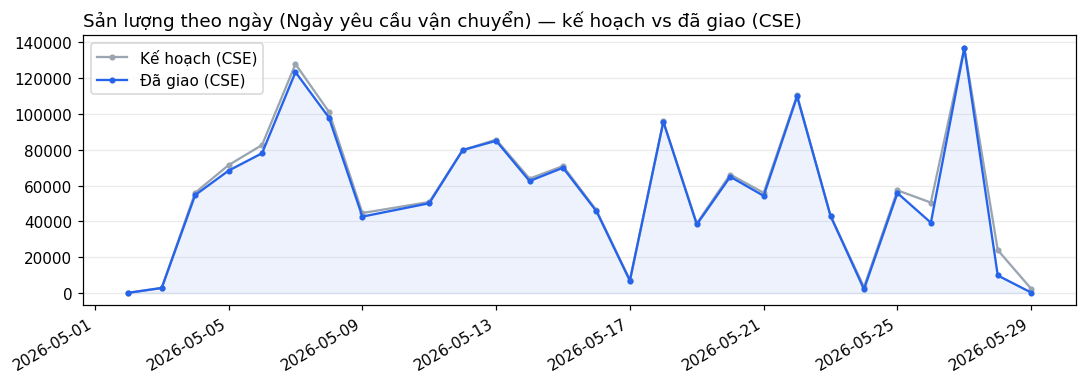

In [170]:
TREND_FROM, TREND_TO, TREND_DATE = '2026-05-01', '2026-05-31', 'RequestDate'   # đổi để xem khoảng khác
t = q(f"""
  SELECT toDate({DT(TREND_DATE)}) AS ngay,
         round(sum({NUM('QuantityOrder')}), 0) AS ke_hoach,
         round(sum({NUM('QuantityBBGN')}), 0) AS da_giao
  FROM {T}
  WHERE toDate({DT(TREND_DATE)}) BETWEEN {{a:Date}} AND {{b:Date}}
  GROUP BY ngay ORDER BY ngay
""", {"a": TREND_FROM, "b": TREND_TO})

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(t['ngay'], t['ke_hoach'], marker='o', ms=3, color=GREY, label='Kế hoạch (CSE)')
ax.plot(t['ngay'], t['da_giao'], marker='o', ms=3, color=ACCENT, label='Đã giao (CSE)')
ax.fill_between(t['ngay'], t['da_giao'], color=ACCENT, alpha=0.08)
ax.set_title(f'Sản lượng theo ngày ({LABELS.get(TREND_DATE, TREND_DATE)}) — kế hoạch vs đã giao (CSE)',
             loc='left', fontweight='medium')
ax.legend(); ax.grid(axis='x', alpha=0); fig.autofmt_xdate(); plt.show()

In [171]:
DAILY_FROM, DAILY_TO, DAILY_DATE = TREND_FROM, TREND_TO, TREND_DATE   # đổi DAILY_DATE='ETA' để đọc on-time theo ngày đến hạn

d = q(f"""
  SELECT toDate({DT(DAILY_DATE)}) AS ngay,
         uniqExact(OrderCode) AS tong_don,
         uniqExactIf(MasterCode, MasterCode != '') AS tong_chuyen,
         round(100 * countIf(DeliveryStatus = 'Hoàn tất') / count(), 1) AS pct_da_giao,
         round(100 * countIf({ONTIME()} AND DeliveryStatus = 'Hoàn tất')
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {DT('DateToCome')} IS NOT NULL
                                AND {DT('ETA')} IS NOT NULL), 0), 1) AS pct_ontime,
         round(100 * countIf({NUM('QuantityBBGN')} >= {NUM('QuantityOrder')} AND DeliveryStatus = 'Hoàn tất'
                             AND {NUM('QuantityOrder')} > 0)
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {NUM('QuantityOrder')} > 0), 0), 1) AS pct_infull,
         round(100 * sum({NUM('QuantityBBGN')}) / nullIf(sum({NUM('QuantityOrder')}), 0), 1) AS fill_rate,
         round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao
  FROM {T}
  WHERE toDate({DT(DAILY_DATE)}) BETWEEN {{a:Date}} AND {{b:Date}}
  GROUP BY ngay ORDER BY ngay
""", {"a": DAILY_FROM, "b": DAILY_TO})

bang = pd.DataFrame({
    'Ngày':          d['ngay'].astype(str),
    'Tổng đơn':      d['tong_don'].map(fmt),
    'Tổng chuyến':   d['tong_chuyen'].map(fmt),
    '% Đã giao':     [f"{rag(v, 95, 85)} {fmt(v)}" for v in d['pct_da_giao']],
    '% On-time':     [f"{rag(v, 95, 90)} {fmt(v)}" for v in d['pct_ontime']],
    '% In-full':     [f"{rag(v, 97, 92)} {fmt(v)}" for v in d['pct_infull']],
    'Fill rate %':   d['fill_rate'].map(fmt),
    'SL giao (CSE)': d['sl_giao'].map(fmt),
})
display(Markdown(f"### KPI theo ngày · {LABELS.get(DAILY_DATE, DAILY_DATE)} · {DAILY_FROM} → {DAILY_TO}"))
display(bang)
print(f"On-time = đến ≤ ETA đơn + {ONTIME_GRACE_MIN}′ · In-full = giao ≥ KH · % tính trên dòng đã 'Hoàn tất'")

### KPI theo ngày · Ngày yêu cầu vận chuyển · 2026-05-01 → 2026-05-31

,Ngày,Tổng đơn,Tổng chuyến,% Đã giao,% On-time,% In-full,Fill rate %,SL giao (CSE)
0,2026-05-02,2,2,🟢 100,🔴 0,🟢 100,100,64
1,2026-05-03,856,5,🟢 100,🟢 100,🟢 100,100,"2,769"
2,2026-05-04,451,134,🟢 99.1,🔴 73.9,🟡 92.6,97.7,"54,705"
3,2026-05-05,"2,300",165,🟡 91.9,🔴 84.3,🟢 98.7,95.7,"68,360"
4,2026-05-06,"1,677",150,🔴 63.6,🔴 86.6,🟡 95,94.5,"78,078"
5,2026-05-07,349,126,🟢 99.4,🔴 77.5,🔴 88.1,96.5,"123,421"
6,2026-05-08,622,162,🟢 99.3,🔴 74,🟡 93.5,96.8,"98,019"
7,2026-05-09,706,108,🔴 42.2,🔴 81,🟢 97,95.5,"42,654"
8,2026-05-11,538,113,🟢 96.4,🔴 76.6,🟢 100,98.6,"50,129"
9,2026-05-12,617,132,🟢 99.8,🔴 75.4,🟢 100,100,"79,843"


On-time = đến ≤ ETA đơn + 30′ · In-full = giao ≥ KH · % tính trên dòng đã 'Hoàn tất'


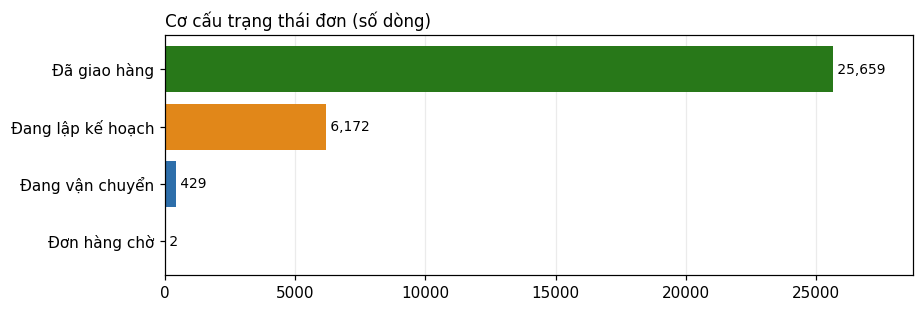

In [172]:
s = q(f"SELECT OrderStatus AS tt, count() AS n FROM {T} GROUP BY tt ORDER BY n DESC")
cmap = {'Đã giao hàng': GREEN, 'Đang vận chuyển': BLUE, 'Đang lập kế hoạch': AMBER, 'Đơn hàng chờ': GREY}
barh([(x or '(rỗng)') for x in s['tt']], list(s['n']),
     'Cơ cấu trạng thái đơn (số dòng)', colors=[cmap.get(x, NAVY) for x in s['tt']])

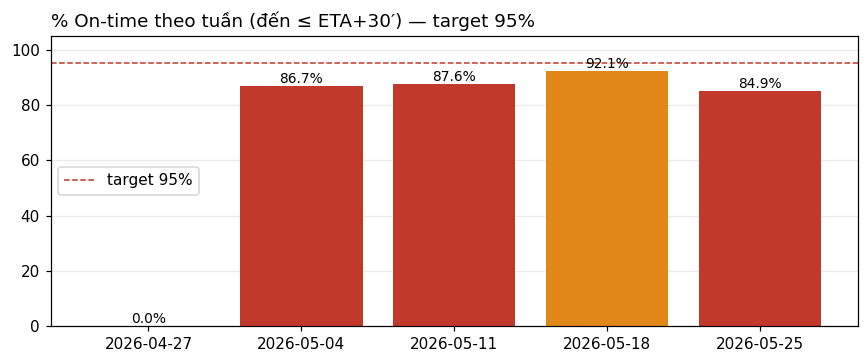

In [173]:
w = q(f"""
  SELECT toMonday(toDate({DT('ETA')})) AS tuan,
         round(100 * countIf({ONTIME()}) / nullIf(count(), 0), 1) AS pct_ontime,
         count() AS n
  FROM {T}
  WHERE DeliveryStatus = 'Hoàn tất' AND {DT('DateToCome')} IS NOT NULL AND {DT('ETA')} IS NOT NULL
    AND toDate({DT('ETA')}) BETWEEN '2026-05-01' AND '2026-05-31'
  GROUP BY tuan ORDER BY tuan
""")
fig, ax = plt.subplots(figsize=(8, 3.4))
colors = [GREEN if v >= 95 else (AMBER if v >= 90 else RED) for v in w['pct_ontime']]
ax.bar(w['tuan'].astype(str), w['pct_ontime'], color=colors)
ax.axhline(95, ls='--', color=RED, lw=1, label='target 95%')
for i, v in enumerate(w['pct_ontime']):
    ax.text(i, v, f"{v}%", ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 105)
ax.set_title(f'% On-time theo tuần (đến ≤ ETA+{ONTIME_GRACE_MIN}′) — target 95%', loc='left', fontweight='medium')
ax.legend(); ax.grid(axis='x', alpha=0); plt.show()

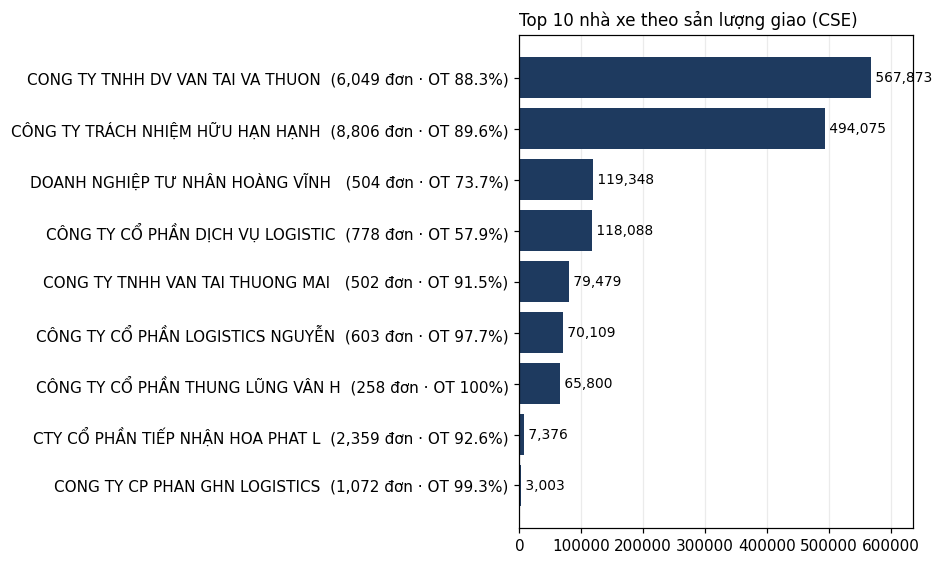

In [174]:
v = q(f"""
  SELECT VendorName AS nha_xe,
         round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao,
         uniqExact(OrderCode) AS so_don,
         round(100 * countIf({ONTIME()} AND DeliveryStatus = 'Hoàn tất')
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {DT('DateToCome')} IS NOT NULL
                                AND {DT('ETA')} IS NOT NULL), 0), 1) AS pct_ontime
  FROM {T} WHERE VendorName != '' GROUP BY nha_xe ORDER BY sl_giao DESC LIMIT 10
""")
labels = [f"{n[:32]}  ({fmt(d)} đơn · OT {fmt(o)}%)" for n, d, o in zip(v['nha_xe'], v['so_don'], v['pct_ontime'])]
barh(labels, list(v['sl_giao']), 'Top 10 nhà xe theo sản lượng giao (CSE)', colors=NAVY)

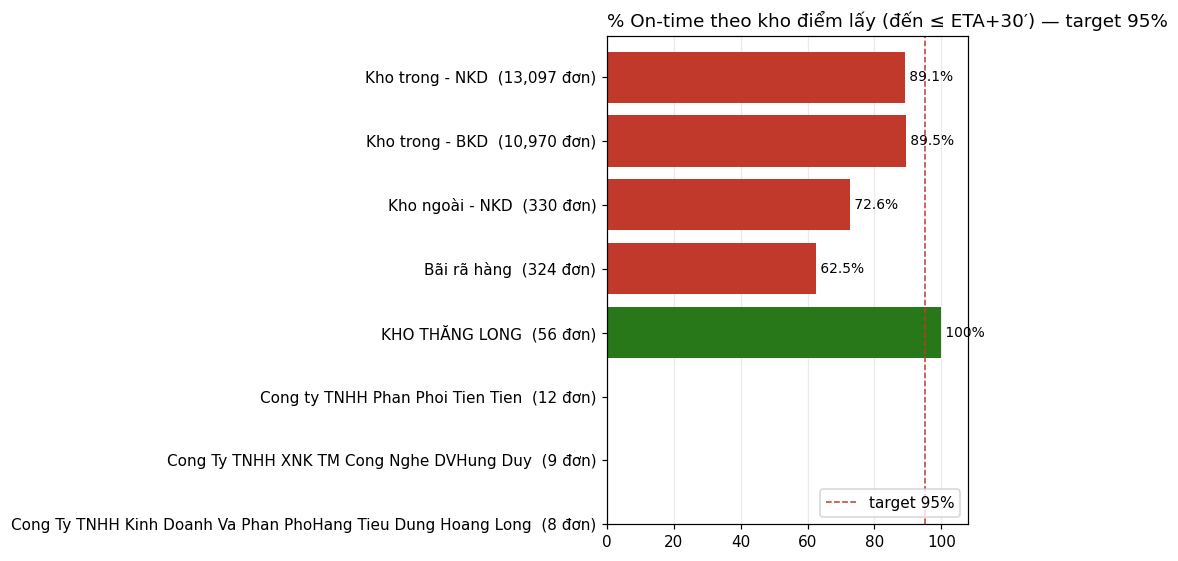

In [175]:
wh = q(f"""
  SELECT if(StockName = '', '(rỗng)', StockName) AS kho,
         uniqExact(OrderCode) AS so_don,
         round(100 * countIf({ONTIME()} AND DeliveryStatus = 'Hoàn tất')
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {DT('DateToCome')} IS NOT NULL
                                AND {DT('ETA')} IS NOT NULL), 0), 1) AS pct_ontime
  FROM {T} WHERE StockName != '' GROUP BY kho ORDER BY so_don DESC LIMIT 8
""")
fig, ax = plt.subplots(figsize=(9, 0.5 * len(wh) + 1.2))
colors = [GREEN if v >= 95 else (AMBER if v >= 90 else RED) for v in wh['pct_ontime']]
ax.barh(range(len(wh)), wh['pct_ontime'], color=colors)
ax.set_yticks(range(len(wh)))
ax.set_yticklabels([f"{k}  ({fmt(d)} đơn)" for k, d in zip(wh['kho'], wh['so_don'])])
ax.invert_yaxis()
ax.axvline(95, ls='--', color=RED, lw=1, label='target 95%')
for i, v in enumerate(wh['pct_ontime']):
    ax.text(v, i, f" {fmt(v)}%", va='center', fontsize=9)
ax.set_xlim(0, 108)
ax.set_title(f'% On-time theo kho điểm lấy (đến ≤ ETA+{ONTIME_GRACE_MIN}′) — target 95%', loc='left', fontweight='medium')
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0); plt.show()

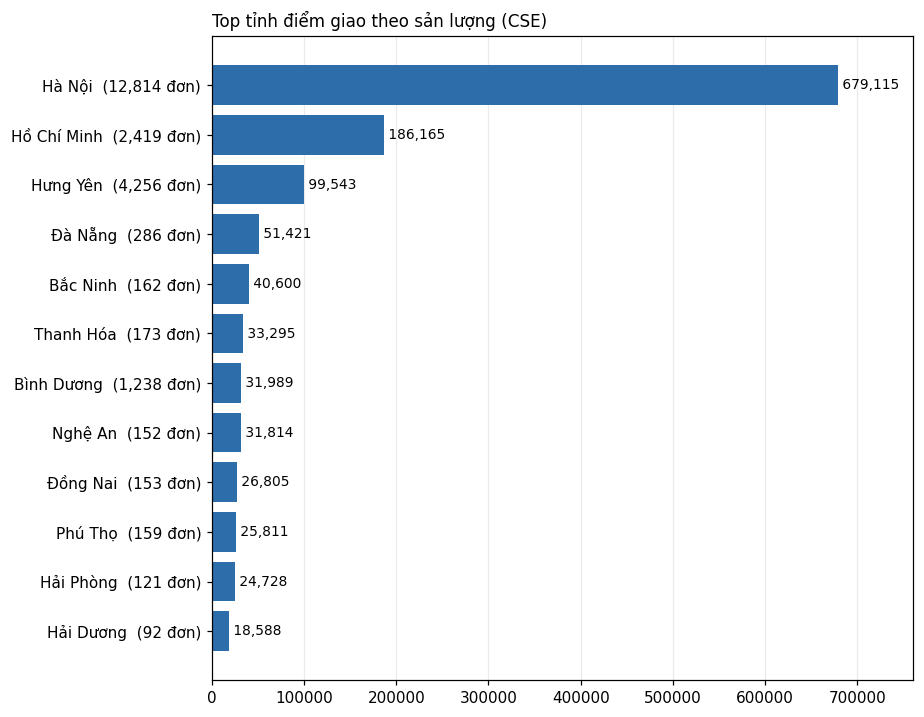

In [176]:
p = q(f"""
  SELECT OPSLocationToProvince AS tinh, round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao,
         uniqExact(OrderCode) AS so_don
  FROM {T} WHERE OPSLocationToProvince != '' GROUP BY tinh ORDER BY sl_giao DESC LIMIT 12
""")
barh([f"{t}  ({fmt(d)} đơn)" for t, d in zip(p['tinh'], p['so_don'])], list(p['sl_giao']),
     'Top tỉnh điểm giao theo sản lượng (CSE)', colors=BLUE)

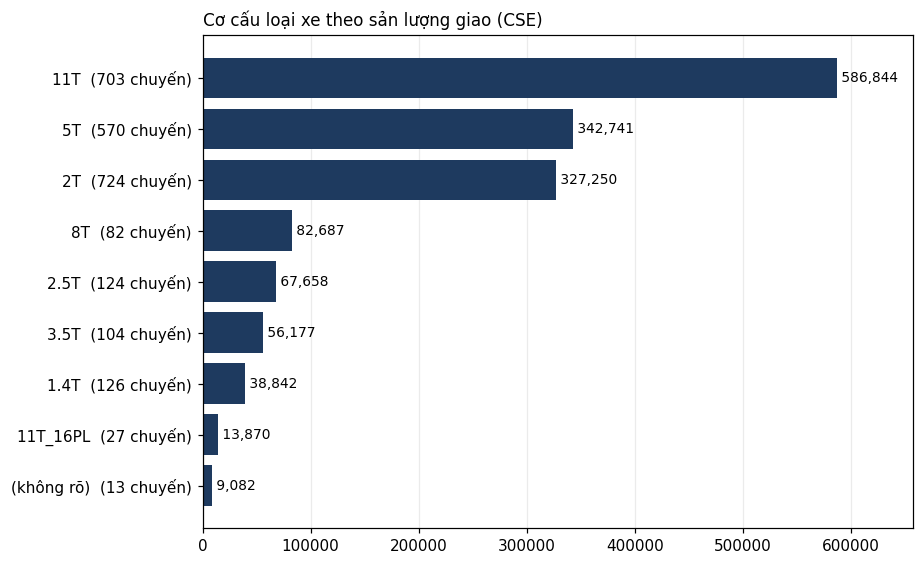

In [177]:
veh = q(f"""
  SELECT if(GroupOfVehicleName = '', '(không rõ)', GroupOfVehicleName) AS loai_xe,
         uniqExactIf(MasterCode, MasterCode != '') AS so_chuyen,
         round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao
  FROM {T} GROUP BY loai_xe ORDER BY sl_giao DESC LIMIT 12
""")
barh([f"{x}  ({fmt(c)} chuyến)" for x, c in zip(veh['loai_xe'], veh['so_chuyen'])], list(veh['sl_giao']),
     'Cơ cấu loại xe theo sản lượng giao (CSE)', colors=NAVY)

## L3 · Bảng xếp hạng
Số liệu chi tiết để lọc/sort thêm — nhà xe (≥ 50 đơn), **kho điểm lấy**, và tỉnh điểm giao.

In [178]:
display(Markdown("**Hiệu suất nhà xe** (≥ 50 đơn)"))
display(q(f"""
  SELECT VendorName AS nha_xe,
         uniqExactIf(MasterCode, MasterCode != '') AS so_chuyen,
         uniqExact(OrderCode) AS so_don,
         round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao,
         round(100 * countIf({ONTIME()} AND DeliveryStatus = 'Hoàn tất')
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {DT('DateToCome')} IS NOT NULL
                                AND {DT('ETA')} IS NOT NULL), 0), 1) AS pct_ontime,
         round(100 * countIf({NUM('QuantityBBGN')} >= {NUM('QuantityOrder')} AND DeliveryStatus = 'Hoàn tất'
                             AND {NUM('QuantityOrder')} > 0)
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {NUM('QuantityOrder')} > 0), 0), 1) AS pct_infull
  FROM {T} WHERE VendorName != '' GROUP BY nha_xe HAVING so_don >= 50 ORDER BY sl_giao DESC LIMIT 20
"""))

**Hiệu suất nhà xe** (≥ 50 đơn)

,nha_xe,so_chuyen,so_don,sl_giao,pct_ontime,pct_infull
0,CONG TY TNHH DV VAN TAI VA THUONG MAI ANH SON VAN TAI VA KHO BAI,954,6049,567873.0,88.3,98.3
1,CÔNG TY TRÁCH NHIỆM HỮU HẠN HẠNH ĐỨC ANH,798,8806,494075.0,89.6,99.4
2,DOANH NGHIỆP TƯ NHÂN HOÀNG VĨNH PHÚC,86,504,119348.0,73.7,97.2
3,CÔNG TY CỔ PHẦN DỊCH VỤ LOGISTICS THĂNG LONG,119,778,118088.0,57.9,98.5
4,CONG TY TNHH VAN TAI THUONG MAI DICH VỤ THANH AN,117,502,79479.0,91.5,97.9
5,CÔNG TY CỔ PHẦN LOGISTICS NGUYỄN PHÁT,119,603,70109.0,97.7,99.6
6,CÔNG TY CỔ PHẦN THUNG LŨNG VÂN HỒ,258,258,65800.0,100.0,100.0
7,CTY CỔ PHẦN TIẾP NHẬN HOA PHAT LOGISTICS,15,2359,7376.0,92.6,100.0
8,CONG TY CP PHAN GHN LOGISTICS,7,1072,3003.0,99.3,100.0


In [179]:
display(Markdown("**Theo kho điểm lấy**"))
display(q(f"""
  SELECT StockName AS kho, StockCode AS ma_kho,
         uniqExact(OrderCode) AS so_don,
         round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao,
         round(100 * countIf({ONTIME()} AND DeliveryStatus = 'Hoàn tất')
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {DT('DateToCome')} IS NOT NULL
                                AND {DT('ETA')} IS NOT NULL), 0), 1) AS pct_ontime,
         round(100 * countIf({NUM('QuantityBBGN')} >= {NUM('QuantityOrder')} AND DeliveryStatus = 'Hoàn tất'
                             AND {NUM('QuantityOrder')} > 0)
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {NUM('QuantityOrder')} > 0), 0), 1) AS pct_infull
  FROM {T} WHERE StockName != '' GROUP BY kho, ma_kho ORDER BY so_don DESC LIMIT 15
"""))

**Theo kho điểm lấy**

,kho,ma_kho,so_don,sl_giao,pct_ontime,pct_infull
0,Kho trong - NKD,NKD,13097,487337.0,89.1,99.5
1,Kho trong - BKD,BKD,10970,787765.0,89.5,98.5
2,Kho ngoài - NKD,VN831,330,169270.0,72.6,94.2
3,Bãi rã hàng,99999,324,40156.0,62.5,98.4
4,KHO THĂNG LONG,VN832,56,14406.0,100.0,100.0
5,Cong Ty TNHH XNK TM Cong Nghe DVHung Duy,6840009,9,987.0,NaN,100.0
6,Cong Ty TNHH Kinh Doanh Va Phan PhoHang Tieu Dung Hoang Long,7120743,8,324.0,NaN,100.0
7,Cong Ty TNHH MTV Lam Dieu,7127929,7,64.0,NaN,100.0
8,Cong Ty TNHH San Xuat Thuong MaiHong Yang,7126236,7,242.0,NaN,100.0
9,Cong ty TNHH - Nam Tien CR,6840039,6,213.0,NaN,100.0


In [180]:
display(Markdown("**Theo tỉnh điểm giao**"))
display(q(f"""
  SELECT OPSLocationToProvince AS tinh, uniqExact(OrderCode) AS so_don,
         round(sum({NUM('QuantityBBGN')}), 0) AS sl_giao,
         round(100 * countIf({ONTIME()} AND DeliveryStatus = 'Hoàn tất')
               / nullIf(countIf(DeliveryStatus = 'Hoàn tất' AND {DT('DateToCome')} IS NOT NULL
                                AND {DT('ETA')} IS NOT NULL), 0), 1) AS pct_ontime
  FROM {T} WHERE OPSLocationToProvince != '' GROUP BY tinh ORDER BY so_don DESC LIMIT 20
"""))

**Theo tỉnh điểm giao**

,tinh,so_don,sl_giao,pct_ontime
0,Hà Nội,12814,679115.0,92.7
1,Hưng Yên,4256,99543.0,93.0
2,Hồ Chí Minh,2419,186165.0,90.9
3,Bình Dương,1238,31989.0,81.2
4,Cần Thơ,338,7937.0,98.1
5,Đà Nẵng,286,51421.0,61.8
6,Gia Lai,221,8481.0,77.8
7,Thanh Hóa,173,33295.0,60.3
8,Bắc Ninh,162,40600.0,76.1
9,Phú Thọ,159,25811.0,59.6


## L4 · Soi chi tiết — theo đơn / chuyến / ngày
Sửa **Tham số** rồi chạy cell tương ứng. Mỗi mức (đơn / chuyến / ngày) có bảng **giao nhận theo CSE**: kế hoạch (`QuantityOrder`) vs giao nhận thực BBGN (`QuantityBBGN`) → **chênh lệch** + cờ 🟢 Đủ / 🔴 Thiếu / 🔵 Vượt / ⏳ Chưa giao. Detail view chỉ hiện nhóm **số lượng + thời gian**; `detail(df, all_cols=True)` để xem hết 144 cột.

In [181]:
ORDER_CODE  = "8482509577"   # mã đơn hàng
MASTER_CODE = "DI0201457"                         # mã chuyến
DAY         = "2026-05-15"                        # ngày YYYY-MM-DD cho summary
DATE_COL    = "MasterATD"   # cột ngày lọc summary: MasterATD|MasterETD|ETD|ETA|DateToCome|DateFromCome|OrderCreatedDate|RequestDate

# Giao nhận (BBGN) theo CSE: kế hoạch QuantityOrder vs giao nhận thực QuantityBBGN
def gn_flag(kh, giaonhan, delivered):
    if not delivered: return '⏳ Chưa giao'
    if kh <= 0:       return '⚪ (không có KH)'
    d = giaonhan - kh
    if d < 0: return '🔴 Thiếu'
    if d > 0: return '🔵 Vượt'
    return '🟢 Đủ'

def gn_table(df, key_label, kh_total=None):
    if df.empty:
        print('Khong co dong nao.'); return None
    d = df.copy()
    d['chenh'] = (d['giaonhan'] - d['kh']).round(0)
    d['trang_thai'] = [gn_flag(k, g, s == 'Hoàn tất')
                       for k, g, s in zip(d['kh'], d['giaonhan'], d['tt_giao'])]
    kh_t = d['kh'].sum() if kh_total is None else kh_total
    gn_t = d['giaonhan'].sum()
    pct = (100 * gn_t / kh_t) if kh_t else float('nan')
    total = pd.DataFrame([{'key': 'TỔNG', 'tt_giao': '', 'kh': kh_t, 'giaonhan': gn_t,
                           'chenh': gn_t - kh_t,
                           'trang_thai': (f'{pct:.1f}% giao nhận' if kh_t else '—')}])
    return pd.concat([d, total], ignore_index=True).rename(columns={
        'key': key_label, 'tt_giao': 'TT giao', 'kh': 'KH (CSE)',
        'giaonhan': 'Giao nhận (CSE)', 'chenh': 'Chênh lệch', 'trang_thai': 'Trạng thái'})

In [182]:
_df = q(f"SELECT * FROM {T} WHERE OrderCode = {{oc:String}}", {"oc": ORDER_CODE})
print(f"OrderCode={ORDER_CODE!r}: {len(_df)} dòng")
_gn = q(f"""
  SELECT if(MasterCode = '', '(chưa lên chuyến)', MasterCode) AS key,
         DeliveryStatus AS tt_giao,
         round({NUM('QuantityOrder')}, 0) AS kh,
         round({NUM('QuantityBBGN')}, 0) AS giaonhan
  FROM {T} WHERE OrderCode = {{oc:String}} ORDER BY MasterCode
""", {"oc": ORDER_CODE})
print("Giao nhận theo CSE — kế hoạch vs thực giao (TỔNG dùng KH đơn, không cộng dồn qua chuyến):")
display(gn_table(_gn, 'Chuyến', kh_total=(_gn['kh'].max() if not _gn.empty else None)))
print("Chi tiết (số lượng + thời gian):")
detail(_df)

OrderCode='8482509577': 1 dòng
Giao nhận theo CSE — kế hoạch vs thực giao (TỔNG dùng KH đơn, không cộng dồn qua chuyến):


,Chuyến,TT giao,KH (CSE),Giao nhận (CSE),Chênh lệch,Trạng thái
0,DI0205710,Hoàn tất,62.0,62.0,0.0,🟢 Đủ
1,TỔNG,,62.0,62.0,0.0,100.0% giao nhận


Chi tiết (số lượng + thời gian):


,Truong,Code,Gia tri
0,Mã chuyến,MasterCode,DI0205710
1,Mã đơn hàng,OrderCode,8482509577
2,Trạng thái đơn,OrderStatus,Đã giao hàng
3,Trạng thái chuyến,MasterStatus,Đã hoàn thành
4,Trạng thái giao hàng,DeliveryStatus,Hoàn tất
5,Số lượng kế hoạch,QuantityOrder,62
6,Số lượng lấy,QuantityTransfer,62
7,Số lượng giao,QuantityBBGN,62
8,Tấn kế hoạch,TonOrder,0.14440399999999998
9,Tấn giao,TonBBGN,0.14440399999999998


In [183]:
_gnt = q(f"""
  SELECT OrderCode AS key, DeliveryStatus AS tt_giao,
         round({NUM('QuantityOrder')}, 0) AS kh,
         round({NUM('QuantityBBGN')}, 0) AS giaonhan
  FROM {T} WHERE MasterCode = {{mc:String}} ORDER BY key
""", {"mc": MASTER_CODE})
print(f"MasterCode={MASTER_CODE!r}: {len(_gnt)} đơn trong chuyến — giao nhận theo CSE")
display(gn_table(_gnt, 'Đơn'))
detail(q(f"SELECT * FROM {T} WHERE MasterCode = {{mc:String}} LIMIT 1", {"mc": MASTER_CODE}))

MasterCode='DI0201457': 1 đơn trong chuyến — giao nhận theo CSE


,Đơn,TT giao,KH (CSE),Giao nhận (CSE),Chênh lệch,Trạng thái
0,HANGCHIEUVE-05052026-000748516,Hoàn tất,34.0,34.0,0.0,🟢 Đủ
1,TỔNG,,34.0,34.0,0.0,100.0% giao nhận


,Truong,Code,Gia tri
0,Mã chuyến,MasterCode,DI0201457
1,Mã đơn hàng,OrderCode,HANGCHIEUVE-05052026-000748516
2,Trạng thái đơn,OrderStatus,Đã giao hàng
3,Trạng thái chuyến,MasterStatus,Đã hoàn thành
4,Trạng thái giao hàng,DeliveryStatus,Hoàn tất
5,Số lượng kế hoạch,QuantityOrder,34
6,Số lượng lấy,QuantityTransfer,34
7,Số lượng giao,QuantityBBGN,34
8,Tấn kế hoạch,TonOrder,0
9,Tấn giao,TonBBGN,0


In [184]:
_w = f"startsWith({DATE_COL}, {{day:String}})"
print(f"Lọc theo {DATE_COL} bắt đầu bằng {DAY!r}")
print("Giao nhận theo CSE — kế hoạch vs thực giao:")
display(q(f"""
  SELECT uniqExact(OrderCode) AS so_don, uniqExactIf(MasterCode, MasterCode != '') AS so_chuyen,
         round(sum({NUM('QuantityOrder')}), 0) AS kh_cse,
         round(sum({NUM('QuantityBBGN')}), 0) AS giaonhan_cse,
         round(sum({NUM('QuantityBBGN')}) - sum({NUM('QuantityOrder')}), 0) AS chenh_lech_cse,
         round(100 * sum({NUM('QuantityBBGN')}) / nullIf(sum({NUM('QuantityOrder')}), 0), 1) AS pct_giaonhan,
         round(sum({NUM('TonBBGN')}), 3) AS tan_giao, round(sum({NUM('CBMBBGN')}), 3) AS khoi_giao
  FROM {T} WHERE {_w}
""", {"day": DAY}))
print("Số đơn theo trạng thái giao:")
display(q(f"SELECT DeliveryStatus, count() AS n FROM {T} WHERE {_w} GROUP BY DeliveryStatus ORDER BY n DESC", {"day": DAY}))

Lọc theo MasterATD bắt đầu bằng '2026-05-15'
Giao nhận theo CSE — kế hoạch vs thực giao:


,so_don,so_chuyen,kh_cse,giaonhan_cse,chenh_lech_cse,pct_giaonhan,tan_giao,khoi_giao
0,1314,88,38030.0,38030.0,0.0,100.0,127.278,1202.164


Số đơn theo trạng thái giao:


,DeliveryStatus,n
0,Hoàn tất,1327


## L5 · Truy vấn tự do
Sửa SQL bên dưới để khai thác thêm. Dùng `{T}`, `DT('cot')`, `NUM('cot')` cho gọn.

In [185]:
q(f"""
  SELECT OrderCode, MasterCode, OrderStatus, DeliveryStatus,
         QuantityBBGN, TonBBGN, OrderCreatedDate, ETD, ETA, DateToCome
  FROM {T} LIMIT 50
""")

,OrderCode,MasterCode,OrderStatus,DeliveryStatus,QuantityBBGN,TonBBGN,OrderCreatedDate,ETD,ETA,DateToCome
0,8472278831,,Đang lập kế hoạch,Chờ,0,0,2026-05-27 14:39:29.668000,2026-05-28 09:00:00,2026-05-28 17:00:00,
1,8482494344,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:03.551000,2026-05-05 00:00:00,2026-05-05 16:00:00,
2,8482494347,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:19.233000,2026-05-05 00:00:00,2026-05-05 16:00:00,
3,8482494348,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:05.612000,2026-05-05 00:00:00,2026-05-05 16:00:00,
4,8482494349,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:23.658000,2026-05-05 00:00:00,2026-05-05 16:00:00,
5,8482494351,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:15.816000,2026-05-05 00:00:00,2026-05-05 16:00:00,
6,8482494352,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:09.942000,2026-05-05 00:00:00,2026-05-05 16:00:00,
7,8482494353,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:22.975000,2026-05-05 00:00:00,2026-05-05 16:00:00,
8,8482494355,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:16.728000,2026-05-05 00:00:00,2026-05-05 16:00:00,
9,8482494357,,Đang lập kế hoạch,Chờ,0,0,2026-05-04 15:31:12.850000,2026-05-05 00:00:00,2026-05-05 16:00:00,
